# Figure 3F: NRF2 core gene concordance analysis

### Objective

Assess whether transcriptional changes observed in SELECT-seq-enriched NRF2 T80K cells recapitulate those observed in clonal NRF2 T80K cells.

### Analysis workflow

1. Use the NRF2 core gene set defined by Strauss & Waters (2026).

2. Calculate differential expression between NRF2 T80K and WT (Unedited) cells in the SELECT-seq dataset using Seurat (`FindMarkers`, Wilcoxon rank-sum test).

3. Obtain differential expression results from the clonal NRF2 T80K dataset reported by Strauss & Waters (2026).

4. Restrict the analysis to highly significant NRF2-responsive genes in the clonal reference dataset (FDR < 1 × 10⁻⁶).

5. Merge the clonal and SELECT-seq differential expression tables by gene symbol.

6. Remove genes with non-finite log₂ fold change values and genes with zero log₂ fold change in both datasets.

7. Calculate directional concordance as the proportion of genes with matching log₂ fold change signs between the clonal and SELECT-seq datasets.

8. Evaluate statistical significance using a two-sided binomial test against an expected concordance rate of 50%.

9. Generate a directionality plot showing clonal NRF2 T80K log₂ fold change values versus SELECT-seq NRF2 T80K log₂ fold change values, with genes coloured according to concordance status.


In [1]:
suppressPackageStartupMessages({
library(tidyverse)
library(reshape2)
library(ggplot2)
library(tidyverse)
library(ggplot2)
library(showtext)
library(sysfonts)
library(ggrepel)
library(dplyr)
library(Seurat)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})
set.seed(100)

In [2]:
#list of NRF2 related genes from Strauss & Waters (2026)
NRF2_core <- c(
  "AKR1B10", "AKR1C1", "AKR1C2", "AKR1C3", "ALDH1A1",
  "ALDH3A", "ALDH7A1", "CBR1", "CES1", "CES1H",
  "EPHX1", "NQO1", "PTGR1", "GSTA1", "GSTA3",
  "GSTM1", "GSTP1", "MGST1", "SULT1A1", "UGT1A",
  "UGT1A6", "UGT2B7", "ABCB6", "ABCC1", "ABCC2",
  "ABCC3", "CAT", "GPX2", "GPX4", "PRDX1",
  "PRDX6", "BLVRB", "FECH", "FPN1", "FTH1",
  "FTL", "HMOX1", "SLC40A1", "GCLC", "GCLM",
  "GGT1", "GSR1", "SLC7A11", "TXN1", "TXNRD1",
  "SRXN1", "G6PD", "PGD", "IDH1", "ME1",
  "TALDO1", "TKT", "CD36", "MARCO", "PSMA1",
  "PSMA4", "PSMA7", "PSMB1", "PSMB2", "PSMB3",
  "PSMB", "PSMB5", "PSMB6", "PSMC1", "PSMC3",
  "PSMD1", "PSMD5", "PSMD", "PSMD11", "PSMD12",
  "PSMD13", "PSME1", "SQSTM1", "CALCOCO2", "ULK1",
  "ATG2", "ATG", "ATG7", "GABARAPL1", "LAMP2",
  "AHR", "ATF3", "ATF4", "CEBPB", "MAFG",
  "PPARG", "PPARGC1B", "RXRA", "KEAP1",
  "TRPA1", "NOTCH1", "PTC"
)

In [3]:
#SELECT-seq log2FC

#load file
WD <- "data/"
sample <- "filtered_counts_NRF2_full.rds"

adata <- readRDS(paste0(WD, sample))

#normalise
adata <- NormalizeData(adata)

#scale
adata <- ScaleData(adata)

#set sample_group as ident
adata <- SetIdent(adata, value=adata@meta.data$sample_group)

# run Wilcoxon test
ref <- "WT from edited pool"
target <- "NRF2 T80K from edited pool"

de_SELECTseq <- FindMarkers(
  adata,
  slot = "data",
  ident.1 = target,
  ident.2 = ref,
  test.use = "wilcox"
) %>%
  tibble::rownames_to_column("gene") %>%
  rename(
    log2FC_SELECTseq = avg_log2FC) %>%
   select(gene, log2FC_SELECTseq)
head(de_SELECTseq)

Normalizing layer: counts

Centering and scaling data matrix

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


,gene,log2FC_SELECTseq
,<chr>,<dbl>
1,NQO1,2.0302052
2,AKR1C1,6.9071473
3,FTL,2.4234425
4,AKR1C3,6.0597360
5,FTH1,0.9048606
6,TKT,0.7796555


In [4]:
#clonal line log2FC (from Strauss & Waters (2026), clonal_lines_analysis_all_cell_lines.html)
samples_to_include <- c("T_K_10") #T80K mutation

de_clonal <- read.csv("data/markers_clonal.csv") %>%
            filter(sample %in% samples_to_include) %>%
            rename(log2FC_clonal = logFC, gene = DE_gene_name, FDR_clonal = FDR) %>%
            select(gene, log2FC_clonal, FDR_clonal)
head(de_clonal)

,gene,log2FC_clonal,FDR_clonal
,<chr>,<dbl>,<dbl>
1,AL645608.6,-0.1510042,2.567846e-02
2,ISG15,0.2391600,1.215290e-12
3,TNFRSF18,0.8878459,3.772006e-02
4,MXRA8,-0.2138628,6.767664e-02
5,MRPL20-AS1,-0.1232411,3.346969e-03
6,MRPL20,0.1207260,1.016849e-12


Shared genes across both DE tables: 2053 
NRF2_core genes absent from merged DE tables: 62 
NRF2_core genes used after removing zero-effect genes: 16 
NRF2_core sign concordance: 14 / 16 ( 87.5 %)
Binomial test against 50% expected concordance:

	Exact binomial test

data:  k and n
number of successes = 14, number of trials = 16, p-value = 0.004181
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.6165238 0.9844864
sample estimates:
probability of success 
                 0.875 



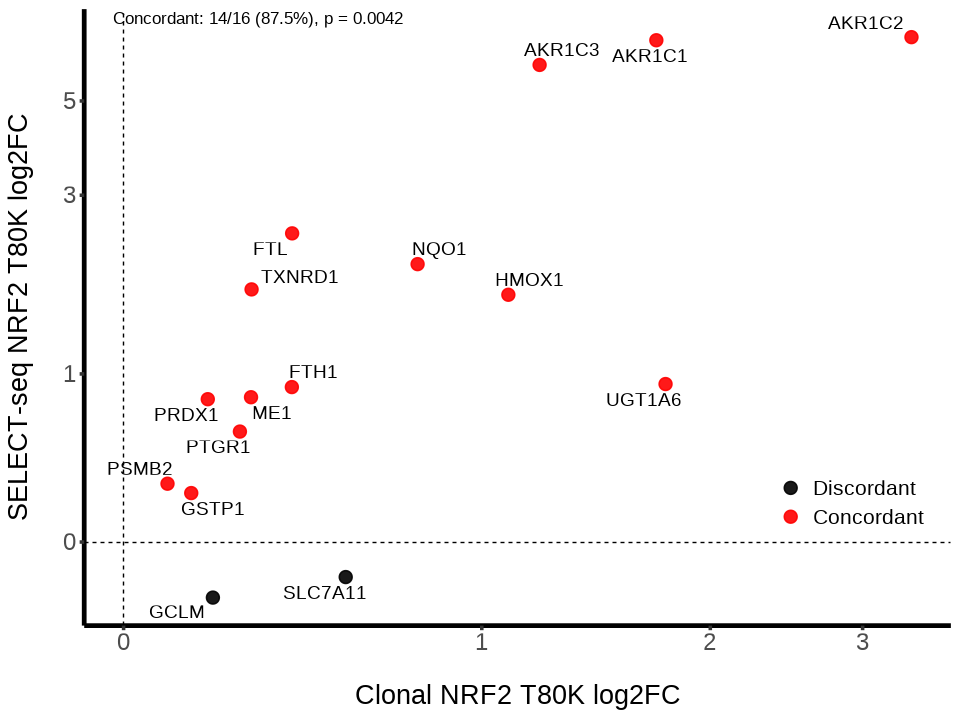

In [17]:
## ------------------------------------------------------------
## 1. Merge datasets and restrict to NRF2 core genes
## ------------------------------------------------------------
merged <- inner_join(
  de_clonal,
  de_SELECTseq,
  by = "gene"
)

cat("Shared genes across both DE tables:", nrow(merged), "\n")

#keep only NRF2_core genes and filter based on FDR in the clonal line)
clonal_fdr_thresh <- 10^-6

merged_nrf2 <- merged %>%
  filter(gene %in% NRF2_core) %>%
  filter(!is.na(FDR_clonal) & FDR_clonal < clonal_fdr_thresh) #filter based on FDR

# Report NRF2 core genes missing from either DE table
missing_nrf2 <- setdiff(NRF2_core, merged$gene)

if (length(missing_nrf2) > 0) {
  cat("NRF2_core genes absent from merged DE tables:", length(missing_nrf2), "\n")
}

# Remove genes with zero effect in both datasets
merged_nrf2 <- merged_nrf2 %>%
  filter(abs(log2FC_clonal) > 0 | abs(log2FC_SELECTseq) > 0)

cat("NRF2_core genes used after removing zero-effect genes:", nrow(merged_nrf2), "\n")

stopifnot(nrow(merged_nrf2) > 0)


## ------------------------------------------------------------
## 2. Directional concordance statistics
## ------------------------------------------------------------

merged_nrf2 <- merged_nrf2 %>%
  mutate(
    concordant = sign(log2FC_clonal) == sign(log2FC_SELECTseq)
  )

k <- sum(merged_nrf2$concordant)
n <- nrow(merged_nrf2)

sign_conc_nrf2 <- k / n

cat("NRF2_core sign concordance:", k, "/", n,
    "(", round(100 * sign_conc_nrf2, 1), "%)\n")

bt_nrf2 <- binom.test(k, n, p = 0.5)

cat("Binomial test against 50% expected concordance:\n")
print(bt_nrf2)

## ------------------------------------------------------------
## 3. Plot
## ------------------------------------------------------------

options(repr.plot.width = 8, repr.plot.height = 6)

p_concordance <- ggplot(
  merged_nrf2,
  aes(x = log2FC_clonal, y = log2FC_SELECTseq)
) +
  geom_point(
    aes(color = concordant),
    size = 3,
    alpha = 0.9
  ) +

  geom_text_repel(
    aes(label = gene),
    size = 5,
    box.padding = 0.3,
    point.padding = 0.1,
    max.overlaps = Inf,
    segment.size = 0.4,
    segment.color = "grey50"
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    linewidth = 0.3
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed",
    linewidth = 0.3
  ) +
  scale_color_manual(
    values = c("FALSE" = "black", "TRUE" = "red"),
    labels = c("FALSE" = "Discordant", "TRUE" = "Concordant")
  ) +
  scale_y_continuous(
    trans = "asinh",
    breaks = c(-1, 0, 1, 3, 5)
  ) +
  scale_x_continuous(
    trans = "asinh",
    breaks = c(-1, 0, 1, 2, 3)
  ) +
  labs(
    x = "Clonal NRF2 T80K log2FC",
    y = "SELECT-seq NRF2 T80K log2FC"
  ) +
  annotate(
    "text",
    x = -Inf,
    y = Inf,
    label = paste0(
      "Concordant: ", k, "/", n,
      " (", round(100 * sign_conc_nrf2, 1), "%)",
      ", p = ",
      format.pval(bt_nrf2$p.value, digits = 2, eps = 0.001)
    ),
    hjust = -0.1,
    vjust = 1.2,
    size = 4.6
  ) +
  theme_classic() +
  theme(
    axis.text = element_text(size = 18),
    axis.title.x = element_text(size = 20, margin = margin(t = 15)),
    axis.title.y = element_text(size = 20, margin = margin(r = 15)),
    legend.position = c(0.9, 0.2),
    legend.text = element_text(size = 16),
    legend.title = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    axis.ticks.x = element_line(size = 0.75),
    axis.ticks.y = element_line(size = 0.75)
  )

p_concordance
ggsave("data/concordance_plot.pdf", plot = last_plot(), width = 8, height = 6, units = "in")

In [7]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] Seurat_5.3.0       SeuratObject_5.2.0 sp_2.2-0           ggrepel_0.9.6     
 [5] showtext_0.9-7     showtextdb_3.0     sysfonts_0.8.9     reshape2_1.4.4    
 [9] lubridate_1.9.4    forcats_1.0.0      stringr_1.5.2      dplyr_1.1.4       
[13] purrr_1.1.0        readr_2.1.5        tidyr_1.3.1        tibble_